# 09 - Image Histograms

For intensity level \(k\), the histogram count is \(h(k)=\#\{(x,y):f(x,y)=k\}\). The normalized histogram is \(p(k)=h(k)/(MN)\), where \(M\times N\) is the image size. A histogram describes frequency but not the spatial location of the pixels.

In [1]:
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_course_root() -> Path:
    """Locate the cloned course repository without a machine-specific path."""
    candidates = []
    configured = os.environ.get("VISION_ROBOTICA_REPO")
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    for candidate in candidates:
        if (candidate / "imagenes").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError(
        "Course repository not found. Run the notebook from the cloned repository root "
        "or define VISION_ROBOTICA_REPO."
    )

ROOT = find_course_root()
COURSE_IMAGES = ROOT / "imagenes"
STUDENT_IMAGES = ROOT / "student_work" / "imagenes"
STUDENT_IMAGES.mkdir(parents=True, exist_ok=True)

def load_rgb(filename: str) -> np.ndarray:
    path = COURSE_IMAGES / filename
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Official course image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Course root: {ROOT}")
print(f"Official images: {COURSE_IMAGES}")
print(f"Student images: {STUDENT_IMAGES}")

Course root: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica
Official images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes
Student images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\student_work\imagenes


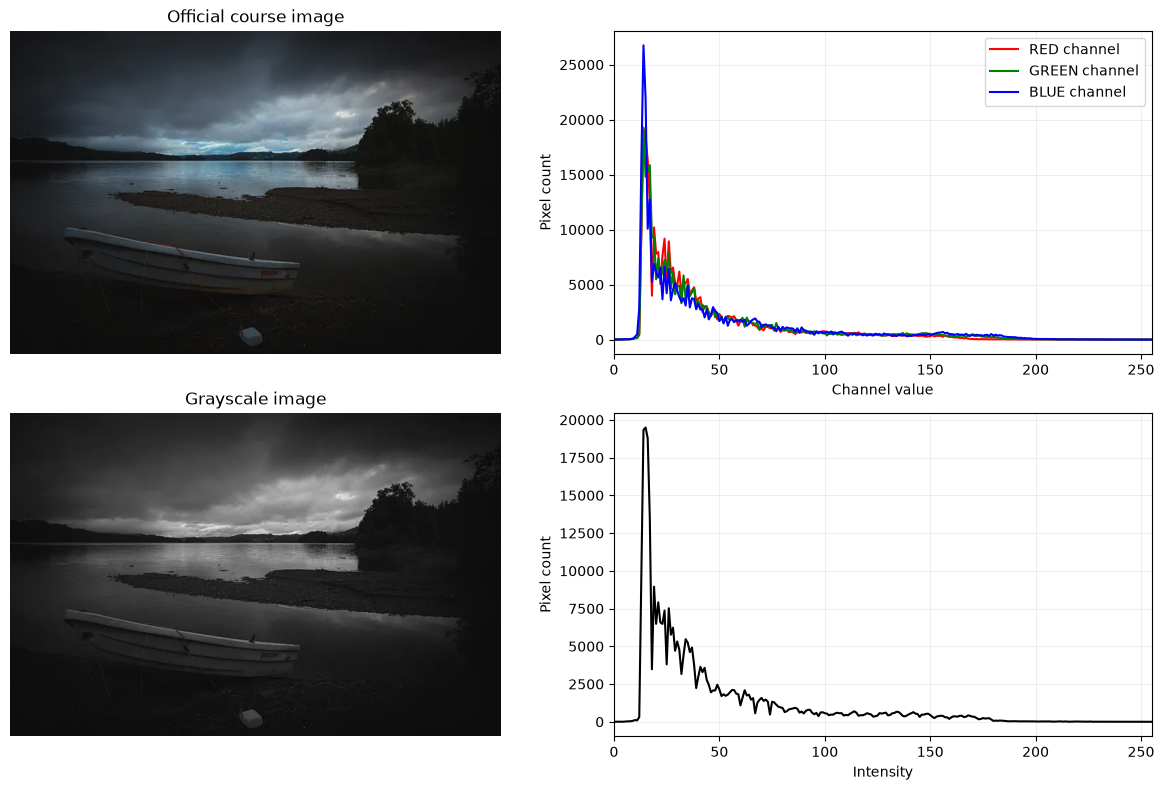

In [2]:
image_rgb = load_rgb("barco.png")
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title("Official course image")
axes[0, 0].axis("off")

colors = ("red", "green", "blue")
for channel, color in enumerate(colors):
    hist = cv2.calcHist([image_rgb], [channel], None, [256], [0, 256]).ravel()
    axes[0, 1].plot(hist, color=color, label=f"{color.upper()} channel")
axes[0, 1].set(xlabel="Channel value", ylabel="Pixel count", xlim=(0, 255))
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.2)

axes[1, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Grayscale image")
axes[1, 0].axis("off")

gray_hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
axes[1, 1].plot(gray_hist, color="black")
axes[1, 1].set(xlabel="Intensity", ylabel="Pixel count", xlim=(0, 255))
axes[1, 1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [3]:
p01, p99 = np.percentile(gray, [1, 99])
occupied = np.count_nonzero(gray_hist)
saturation = np.mean((gray == 0) | (gray == 255))
print(f"Mean intensity: {gray.mean():.2f}")
print(f"Standard deviation: {gray.std():.2f}")
print(f"1st-99th percentile range: [{p01:.1f}, {p99:.1f}]")
print(f"Occupied intensity levels: {occupied}/256")
print(f"Saturation ratio: {saturation:.4f}")

Mean intensity: 45.49
Standard deviation: 38.77
1st-99th percentile range: [13.0, 171.0]
Occupied intensity levels: 237/256
Saturation ratio: 0.0000


## Interpretation for robot vision

A narrow histogram can indicate low global contrast, but it does not prove that task-relevant edges are weak. A concentration near zero can indicate underexposure, dark surfaces, or a scene that is physically dark. Exposure decisions should combine histogram evidence with the expected scene, camera settings, and a downstream metric.